**Import needed libraries**

In [1]:
import pandas as pd
import seaborn as sns
import plotly_express as px
import plotly.io as pio
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import warnings
import datetime

pio.renderers.default = "notebook_connected"    #måste använda detta annars mina seaborn plotar funkar ej
warnings.filterwarnings('ignore')  # gör så att ni slipper se icke kritiska felmeddelanden

## 1 - Getting started

This project will be centered around the Chicago Crime & selected Census data. Start of by downloading both datasets.

**1.1** Read through the documentation for both datasets. Do this *thoroughly*!

Chicago crime data : https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-Present/ijzp-q8t2

Chicago census data : https://data.cityofchicago.org/Health-Human-Services/Census-Data-Selected-socioeconomic-indicators-in-C/kn9c-c2s2



**1.2** Now download both datasets as .csv files. You get the option to download by frist clicking on the 'Export' tab. Make sure you select the data in CSV format.

Be mindful that the crime dataset is over 2GB in size, so it might take awhile to download.

Once downloaded, rename the files chicago_crime.csv & chicago_census.csv, respectively, and put them in the same folder as this notebook.

**1.3** Load data. The following reads should now work.

In [2]:
chicago_crime_2001_to_2025_df = pd.read_csv('chicago_crime.csv')
chicago_census_2008_to_2012_df = pd.read_csv('chicago_census.csv')

**1.4** The census data only contains records that apply for the period 2008-2012, while the crime dataset runs from 2001-2024. 

Therefore, begin by filtering the crime data so that you get a dataframe that contains records only for the period 2008-2012. 

*Hint*: You'll be filtering based on date quite alot in this project, and it's therefore very advisable to transform the existing *Date* column into datetime-format. 

To simplify further, you could perhaps also create new columns that indicate *Year*, *Month*, *Day* and *Hour*. 

You might also find that other types of indicator columns could be useful. Feel free to come back and add them here later.

**Important:** For the remainder of this project, we will only work with data for the year 2008-2012.

In [3]:
# Convert the 'Date' column to datetime format

chicago_crime_2001_to_2025_df['Date'] = pd.to_datetime(chicago_crime_2001_to_2025_df['Date'], format='%m/%d/%Y %I:%M:%S %p')
chicago_crime_2001_to_2025_df['Date']

0         2025-11-04
1         2025-11-04
2         2025-11-04
3         2025-11-04
4         2025-11-04
             ...    
8440404   2001-01-01
8440405   2001-01-01
8440406   2001-01-01
8440407   2001-01-01
8440408   2001-01-01
Name: Date, Length: 8440409, dtype: datetime64[ns]

In [4]:
chicago_crime_2001_to_2025_df['month'] = chicago_crime_2001_to_2025_df['Date'].dt.month
chicago_crime_2001_to_2025_df['day'] = chicago_crime_2001_to_2025_df['Date'].dt.day
chicago_crime_2001_to_2025_df['hour'] = chicago_crime_2001_to_2025_df['Date'].dt.hour
chicago_crime_2001_to_2025_df['minutes'] = chicago_crime_2001_to_2025_df['Date'].dt.minute
chicago_crime_2001_to_2025_df['weekday'] = chicago_crime_2001_to_2025_df['Date'].dt.day_name()

In [5]:
# create a new dataframe with crime records only the period 2008-2012

year_2008_to_2012_filter = chicago_crime_2001_to_2025_df['Date'].dt.year.between(2008, 2012)

chicago_crime_2008_to_2012_df = chicago_crime_2001_to_2025_df[year_2008_to_2012_filter].reset_index(drop=True)

# 2 - Cleaning up the mess

**Note:** The rest of the problems don't really require you to finish this section - you could revisit these questions at a later time. 

Bear in mind though that the numbers you aquire in the problems ahead may or may not change a bit, depending on how you choose to treat the duplicates and missing values here.  

**2.1** How many duplicated rows are there in crime data set? If there are any, remove them.

In [6]:
chicago_crime_2008_to_2012_df.duplicated().sum()    # No duplicated founded

np.int64(0)

**2.2** What columns in the crime dataset has missing values, and how many are they?

In [7]:
are_null = chicago_crime_2008_to_2012_df.isnull()
are_null.sum()

ID                          0
Case Number                 0
Date                        0
Block                       0
IUCR                        0
Primary Type                0
Description                 0
Location Description     1062
Arrest                      0
Domestic                    0
Beat                        0
District                   40
Ward                       46
Community Area            869
FBI Code                    0
X Coordinate            16431
Y Coordinate            16431
Year                        0
Updated On                  0
Latitude                16431
Longitude               16431
Location                16431
month                       0
day                         0
hour                        0
minutes                     0
weekday                     0
dtype: int64

**2.3** Now, for all the columns with missing values you identified, chose one of the following:

        a) remove the entire row with the missing value
        b) replace the missing values with another suitable value
        c) don't do anything, leave the missing values as is

All options above are completely valid! However, I want you to, for all columns with missing values, **clearly** argue for why you chose to do what you do.

In [8]:
#getting a better view of all the columns and their values 

chicago_crime_2008_to_2012_df.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Year,Updated On,Latitude,Longitude,Location,month,day,hour,minutes,weekday
0,8953937,HW102973,2012-12-31 23:58:00,037XX N NORA AVE,0610,BURGLARY,FORCIBLE ENTRY,RESIDENCE-GARAGE,False,False,...,2012,02/10/2018 03:50:01 PM,41.947762,-87.802171,"(41.947761848, -87.802170774)",12,31,23,58,Monday
1,8950836,HW100039,2012-12-31 23:55:00,0000X E OHIO ST,2890,PUBLIC PEACE VIOLATION,OTHER VIOLATION,SIDEWALK,True,False,...,2012,09/23/2025 03:41:47 PM,41.892508,-87.626224,"(41.892507592, -87.626223996)",12,31,23,55,Monday
2,8950918,HW100021,2012-12-31 23:55:00,035XX W MONTROSE AVE,0610,BURGLARY,FORCIBLE ENTRY,OTHER,False,False,...,2012,02/10/2018 03:50:01 PM,41.961089,-87.716315,"(41.961089289, -87.716314748)",12,31,23,55,Monday
3,8954299,HW100700,2012-12-31 23:55:00,058XX S MARYLAND AVE,0890,THEFT,FROM BUILDING,HOSPITAL BUILDING/GROUNDS,False,False,...,2012,02/10/2018 03:50:01 PM,41.788699,-87.604954,"(41.788699253, -87.604954085)",12,31,23,55,Monday
4,8951459,HW100757,2012-12-31 23:50:00,028XX N HALSTED ST,0890,THEFT,FROM BUILDING,RESIDENCE,False,False,...,2012,02/10/2018 03:50:01 PM,41.933894,-87.649053,"(41.933894393, -87.649052922)",12,31,23,50,Monday


In [9]:
'''
Some of the columns with missing values are irrelevant data and we don't need these rows for mapping. That's why i am deciding to simply keep them NaN and not fill them with any other data so they can continue stay numeric. I will be filling rows with the missing value from Location Description column with the "Unknown" value because that will not affect anything in our data and it is the suitable value for that column
'''

filled_col = chicago_crime_2008_to_2012_df['Location Description'].fillna('Unknown', inplace=True)
chicago_crime_2008_to_2012_df.isna().sum()        # checking that the NaN values on Location Description are gone and filled with Unknown 

ID                          0
Case Number                 0
Date                        0
Block                       0
IUCR                        0
Primary Type                0
Description                 0
Location Description        0
Arrest                      0
Domestic                    0
Beat                        0
District                   40
Ward                       46
Community Area            869
FBI Code                    0
X Coordinate            16431
Y Coordinate            16431
Year                        0
Updated On                  0
Latitude                16431
Longitude               16431
Location                16431
month                       0
day                         0
hour                        0
minutes                     0
weekday                     0
dtype: int64

## 3 - The Birds Eye

**3.1** Do some exploratory analysis on the dataset and try to get a sense of the data you're working with.

In [10]:
chicago_crime_2008_to_2012_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1879047 entries, 0 to 1879046
Data columns (total 27 columns):
 #   Column                Dtype         
---  ------                -----         
 0   ID                    int64         
 1   Case Number           object        
 2   Date                  datetime64[ns]
 3   Block                 object        
 4   IUCR                  object        
 5   Primary Type          object        
 6   Description           object        
 7   Location Description  object        
 8   Arrest                bool          
 9   Domestic              bool          
 10  Beat                  int64         
 11  District              float64       
 12  Ward                  float64       
 13  Community Area        float64       
 14  FBI Code              object        
 15  X Coordinate          float64       
 16  Y Coordinate          float64       
 17  Year                  int64         
 18  Updated On            object        
 19  

In [11]:
chicago_census_2008_to_2012_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 9 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Community Area Number                         77 non-null     float64
 1   COMMUNITY AREA NAME                           78 non-null     object 
 2   PERCENT OF HOUSING CROWDED                    78 non-null     float64
 3   PERCENT HOUSEHOLDS BELOW POVERTY              78 non-null     float64
 4   PERCENT AGED 16+ UNEMPLOYED                   78 non-null     float64
 5   PERCENT AGED 25+ WITHOUT HIGH SCHOOL DIPLOMA  78 non-null     float64
 6   PERCENT AGED UNDER 18 OR OVER 64              78 non-null     float64
 7   PER CAPITA INCOME                             78 non-null     int64  
 8   HARDSHIP INDEX                                77 non-null     float64
dtypes: float64(7), int64(1), object(1)
memory usage: 5.6+ KB


**3.1** How many crimes records exists for the period 2008-2012, in total?

In [12]:
crime_records = chicago_crime_2008_to_2012_df['Primary Type'].value_counts()
print(crime_records)
print(f'Total crime record for the period 2008-2012 is: {crime_records.sum()}')


Primary Type
THEFT                               396789
BATTERY                             329385
CRIMINAL DAMAGE                     214408
NARCOTICS                           207540
BURGLARY                            128871
OTHER OFFENSE                       111876
ASSAULT                             110157
MOTOR VEHICLE THEFT                  89270
ROBBERY                              74426
DECEPTIVE PRACTICE                   67966
CRIMINAL TRESPASS                    49437
WEAPONS VIOLATION                    19527
PROSTITUTION                         16193
PUBLIC PEACE VIOLATION               15800
OFFENSE INVOLVING CHILDREN           12750
CRIM SEXUAL ASSAULT                   7029
SEX OFFENSE                           6101
GAMBLING                              4577
INTERFERENCE WITH PUBLIC OFFICER      4225
LIQUOR LAW VIOLATION                  3587
ARSON                                 2755
HOMICIDE                              2365
KIDNAPPING                            146

***This code counts how many times each type of crime occurred between 2008 and 2012***

**3.2** What's the number of recorded crimes each of the years, individually? 

**Method 1 to solve this problem:**

In [13]:
for year in range(2008, 2013):
    mask = chicago_crime_2008_to_2012_df['Date'].dt.year == year
    total = chicago_crime_2008_to_2012_df[mask]['Primary Type'].value_counts().sum()
    print(f"Recorded crimes for year {year}: {total}")

Recorded crimes for year 2008: 427212
Recorded crimes for year 2009: 392862
Recorded crimes for year 2010: 370561
Recorded crimes for year 2011: 352045
Recorded crimes for year 2012: 336367


***This code loops through each year from 2008 to 2012 and counts all crimes recorded in that year. For each year, it prints the total number of crime records.***

**Method 2**

In [14]:
total_crimes_2008 = chicago_crime_2008_to_2012_df['Date'].dt.year == 2008
total_crimes_2008 = chicago_crime_2008_to_2012_df[total_crimes_2008]['Primary Type']
print(f'Recorded crimes for year 2008 is {total_crimes_2008.shape[0]}')

total_crimes_2009 = chicago_crime_2008_to_2012_df['Date'].dt.year == 2009
total_crimes_2009 = chicago_crime_2008_to_2012_df[total_crimes_2009]['Primary Type']
print(f'Recorded crimes for year 2009 is {total_crimes_2009.shape[0]}')

total_crimes_2010 = chicago_crime_2008_to_2012_df['Date'].dt.year == 2010
total_crimes_2010 = chicago_crime_2008_to_2012_df[total_crimes_2010]['Primary Type']
print(f'Recorded crimes for year 2010 is {total_crimes_2010.shape[0]}')

total_crimes_2011 = chicago_crime_2008_to_2012_df['Date'].dt.year == 2011
total_crimes_2011 = chicago_crime_2008_to_2012_df[total_crimes_2011]['Primary Type']
print(f'Recorded crimes for year 2011 is {total_crimes_2011.shape[0]}')

total_crimes_2012 = chicago_crime_2008_to_2012_df['Date'].dt.year == 2012
total_crimes_2012 = chicago_crime_2008_to_2012_df[total_crimes_2012]['Primary Type']
print(f'Recorded crimes for year 2012 is {total_crimes_2012.shape[0]}')


Recorded crimes for year 2008 is 427212
Recorded crimes for year 2009 is 392862
Recorded crimes for year 2010 is 370561
Recorded crimes for year 2011 is 352045
Recorded crimes for year 2012 is 336367


***This code counts all crimes for each year from 2008 to 2012 by filtering the DataFrame based on the Date column, then selects the Primary Type column and calculates the total number of records per year. It prints the total crimes for each year, giving a yearly trend of crime occurrences.***

**3.3** Has the number of recorded crimes increased, decreased or remained stable over said period?

In [15]:
years = sorted(chicago_crime_2008_to_2012_df['Date'].dt.year.unique())
total = [chicago_crime_2008_to_2012_df[chicago_crime_2008_to_2012_df['Date'].dt.year ==y]['Primary Type'].count()for y in years]

trend_df = pd.DataFrame({
    'Year': years,
    'Total Crimes': total
})

fig = px.line(trend_df, x='Year', y='Total Crimes',title='Recorded crimes 2008-2012' ,markers=True)
fig.update_xaxes(dtick=1)
fig.show()

***The plot shows how many crimes were recorded each year. The numbers go down every year, meaning crimes were reported less and less from 2008 to 2012. In simple terms, Chicago had fewer reported crimes each year during this period.***

**3.4** By how many percentage points has the crime rate increased/decreased over this period? 

Hint: You only need to compare the number of crime records from 2008 with the number of crime records from 2012.

In [16]:
crime_perc = ((total_crimes_2012.shape[0] - total_crimes_2008.shape[0]) / total_crimes_2008.shape[0]) * 100
crime_perc = round(crime_perc, 2)
print(f'The crime rate for the period 2008-2012 is: {crime_perc}%')

if crime_perc <= 0:
    print('Crime dropped. Batman must have moved to Chicago!')
else:
    print('Crime went up…to many donut breaks?')


The crime rate for the period 2008-2012 is: -21.26%
Crime dropped. Batman must have moved to Chicago!


***This calculation shows the percentage change in total crimes from 2008 to 2012. The result tells us if overall crime went up or down. In this case, the percentage is negative, meaning crime dropped over the years. The print message is a fun way to say the city became a bit safer.***

**3.5** Which primary crime types have increasing crime rates, and which ones have decreasing crime rates, when comparing 2008 to 2012?

In [17]:
crimes_2008 = total_crimes_2008.value_counts()
crimes_2012 = total_crimes_2012.value_counts()

combined_df = pd.DataFrame({
    '2008': crimes_2008,
    '2012': crimes_2012
})

combined_df['Change'] = combined_df['2012'] - combined_df['2008']

increased = combined_df[combined_df['Change']> 0].sort_values('Change', ascending=False).head(3)
decreased = combined_df[combined_df['Change']< 0].sort_values('Change', ascending=True).head(3)

print(increased)
print(decreased)


                                  2008  2012  Change
Primary Type                                        
INTERFERENCE WITH PUBLIC OFFICER   580  1228     648
WEAPONS VIOLATION                 3877  3907      30
CRIMINAL SEXUAL ASSAULT             66    90      24
                  2008   2012  Change
Primary Type                         
CRIMINAL DAMAGE  52843  35855  -16988
BATTERY          75930  59132  -16798
THEFT            88437  75464  -12973


***This shows which crime types increased the most and which decreased the most between 2008 and 2012. The first table lists the three crimes that went up the most, and the second table lists the three crimes that went down the most. It helps to see where the city is improving and where it might need more focus.***

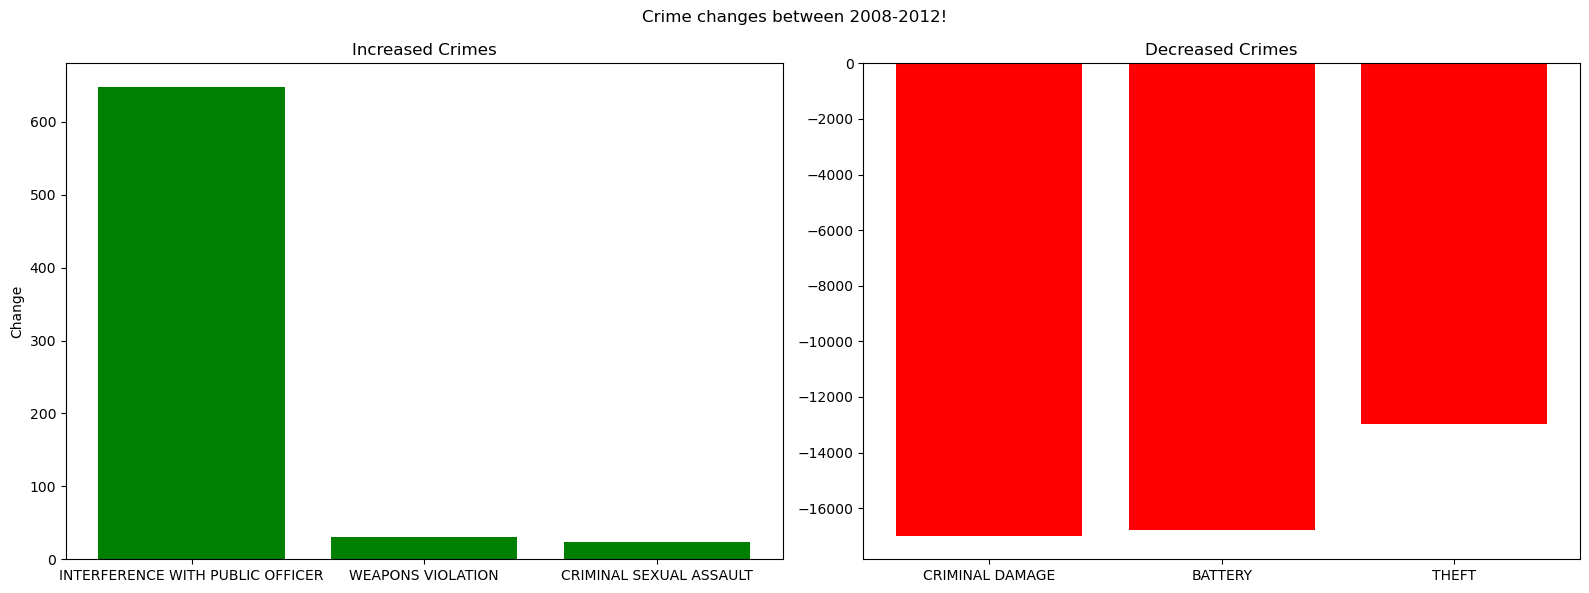

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Crime changes between 2008-2012!')

# Increased crimes
ax1.bar(increased.index, increased['Change'], color='green')
ax1.set_title("Increased Crimes")
ax1.set_ylabel("Change")
ax1.tick_params(axis='x')

# Decreased crimes
ax2.bar(decreased.index, decreased['Change'], color='red')
ax2.set_title("Decreased Crimes")
ax2.tick_params(axis='x')
plt.tight_layout()
plt.show()


***Here i have 2 different plots showing the result of increased and decreased crimes***

# 4 - Chicago Police Departement performance assesment

**4.1** How many recorded crimes have in total led to an arrest? What's the corresponding arrest percentage?

In [19]:
arrest_rate = chicago_crime_2008_to_2012_df['Arrest'].sum()
total_records = len(chicago_crime_2008_to_2012_df)

arrest_percentage = round((arrest_rate / total_records) * 100, 2)

print(f'Total number of crimes that have led to an arrest is: {arrest_rate}!')
print(f'The arrest percentage for all crimes is: {arrest_percentage}%')


Total number of crimes that have led to an arrest is: 508427!
The arrest percentage for all crimes is: 27.06%


***This calculates how many crimes led to an arrest out of all recorded crimes. The first number shows the total arrests, and the percentage tells us roughly how often crimes result in someone being arrested.***

**4.2** Has the arrest rate percentage been increasing, decreasing or remained stable over these years?

In [20]:
total_arrest_per_year = [chicago_crime_2008_to_2012_df[chicago_crime_2008_to_2012_df['Date'].dt.year == y]['Arrest'].count()for y in years]

arrest_df = pd.DataFrame({
    'Year': years,
    'Arrests': total_arrest_per_year
})

fig = px.line(arrest_df, x='Year', y='Arrests', title='Arrests over years!' ,markers=True)
fig.update_xaxes(dtick=1)
fig.show()

**4.3** For the Year 2011, which month has the highest arrest percentage?

In [21]:
# Count arrests per month
highest_month_num = (chicago_crime_2008_to_2012_df[chicago_crime_2008_to_2012_df['Arrest'] == True]['Date'].dt.month.value_counts())

# Month converter
month_converter = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}

highest_month_num_idx = highest_month_num.idxmax()

# Convert to name
highest_month_name = month_converter[highest_month_num_idx]

print("Highest arrest month:", highest_month_name)

Highest arrest month: Aug


***This finds which month had the most arrests. First, it counts all arrests per month. Then it picks the month with the highest count and converts it from a number to a month name. The result tells us the month when arrests were most frequent.***

In [22]:
monthly_arrests_df = highest_month_num.sort_index().reset_index()
monthly_arrests_df.columns = ['Month', 'Arrests']

# Convert month numbers to names
monthly_arrests_df['Month'] = monthly_arrests_df['Month'].map(month_converter)

# Plot
fig = px.bar(
    monthly_arrests_df,
    x='Month',
    y='Arrests',
    title='Total Arrests per Month (2011)',
    text='Arrests'
)

fig.update_traces(textposition='outside')
fig.update_layout(yaxis_title='Number of Arrests')

fig.show()

***Here i plot the total arrest per month for the year of 2011.***

**4.4** For the same year, and the particular month of you've identified in question 4.3, which primary crime type has the highest number of arrests?

In [23]:
year_of_interest = 2011

filtered_df = chicago_crime_2008_to_2012_df[
    (chicago_crime_2008_to_2012_df['Date'].dt.year == year_of_interest) &
    (chicago_crime_2008_to_2012_df['Date'].dt.month == highest_month_num_idx) &
    (chicago_crime_2008_to_2012_df['Arrest'] == True)
]

#Find the primary crime type with most arrests
top_crime_type = filtered_df['Primary Type'].value_counts().idxmax()
top_crime_count = filtered_df['Primary Type'].value_counts().max()

print(f"For {highest_month_name} {year_of_interest}, the primary crime with most arrests is:")
print(f"{top_crime_type} with {top_crime_count} arrests.")

For Aug 2011, the primary crime with most arrests is:
NARCOTICS with 3525 arrests.


***This looks at the year 2011 and the month we found earlier as having the most arrests. It filters the dataset to only include arrests during that month and year. Then it finds which primary crime type had the most arrests and how many. The result tells us the crime that led to the highest number of arrests in that month.***

# 5 - Troubles at home

**5.1** How many recorded crimes are domestic?

In [24]:
domestic_crimes = chicago_crime_2008_to_2012_df['Domestic']==True
domestic_crimes = chicago_crime_2008_to_2012_df[domestic_crimes].shape[0]

print(f'The number of recorded crimes that are domestic is: {domestic_crimes}')

The number of recorded crimes that are domestic is: 309845


***This code counts how many crimes in the dataset are marked as domestic. It filters the dataset for rows where Domestic is True and then gets the total number of these rows. The printed result tells you the total number of domestic crimes recorded.***

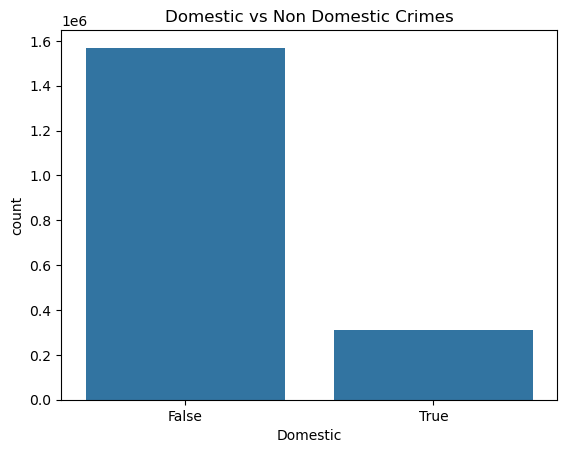

In [82]:
sns.countplot(data=chicago_crime_2008_to_2012_df, x='Domestic')
plt.title("Domestic vs Non Domestic Crimes")
plt.show()

**5.2** How many domestic recorded crimes are of the primary type *offense involving children*?

In [26]:
mask_children = chicago_crime_2008_to_2012_df['Primary Type'].str.contains("CHILD", case=False, na=False)
children_related = chicago_crime_2008_to_2012_df[mask_children]
print(f'There are: {children_related.shape[0]} domestic recorded crimes of the primary type offense involving children!')

There are: 12750 domestic recorded crimes of the primary type offense involving children!


***This shows how many offenses in the dataset specifically involve children.***

**5.3** How much more likely is it that an offense involving children is domestic?

In [27]:
children_domestic = chicago_crime_2008_to_2012_df[mask & (chicago_crime_2008_to_2012_df['Domestic'] == True)].shape[0]
non_domestic_children = chicago_crime_2008_to_2012_df[mask & (chicago_crime_2008_to_2012_df['Domestic'] == False)].shape[0]

***This shows how many of the crimes are domestic and not by creating a mask to filter it.***

In [28]:
pie_df = pd.DataFrame({
    "Category": ["Domestic", "Non-Domestic"],
    "Count": [children_domestic, non_domestic_children]
})

fig = px.pie(
    pie_df,
    names="Category",
    values="Count",
    title="Children-Related Crimes: Domestic vs Non-Domestic"
)

fig.update_traces(textinfo="percent+label")
fig.show()


**5.4** What's the worst weekday in terms of number of domestic offenses involving children? How does it compare to the other weekdays?

In [29]:
# Extract day of week
children_related['day_of_week'] = children_related['Date'].dt.day_name()

# Count by day of week
day_child_count = children_related['day_of_week'].value_counts().reset_index()
day_child_count.columns = ['day_of_week', 'Count']

print(day_child_count)


  day_of_week  Count
0      Friday   2357
1    Saturday   1963
2      Sunday   1930
3    Thursday   1676
4     Tuesday   1660
5   Wednesday   1620
6      Monday   1544


***This shows how crimes involving children are distributed across the days of the week. We can see which days have more incidents and which days are relatively safer.***

In [30]:
fig = px.bar(
    day_child_count,
    x='day_of_week',
    y='Count',
    title='Children related crimes by day of week',
    labels={'day_of_week':'Weekday'}
)

fig.show()


**5.5** What's the distribution, in terms of number of records, for domestic crimes of sexual character that involves children? What's the arrest rate (%) for each? 

In [31]:
mask_sex = chicago_crime_2008_to_2012_df['Description'].str.contains("SEX", case=False, na=False)
children_crimes_mask = chicago_crime_2008_to_2012_df[mask_children & mask_sex & domestic_crimes]
children_sex_crimes = children_crimes_mask['Description'].value_counts()
mask_arrest = children_crimes_mask[children_crimes_mask['Arrest'] == True]

***This is counting all domestic crimes involving children that are of a sexual nature. Then we separate the ones that led to an arrest, so we can later calculate how often these crimes result in arrests.***

In [32]:
arrest_percentages = {}

for desc in children_sex_crimes.index:
    subset = children_crimes_mask[children_crimes_mask['Description'] == desc]
    arrests = subset[subset['Arrest'] == True]

    arrest_rate = (len(arrests) / len(subset)) * 100
    arrest_percentages[desc] = arrest_rate

# Convert to DataFrame
arrest_percentages_df = pd.DataFrame.from_dict(arrest_percentages, orient='index', columns=['Arrest'])


***This code calculates the arrest rate for each type of sexual crime involving children. For each crime, it finds how many cases had an arrest, divides by total cases, and turns it into a percentage. Then it saves all percentages in a DataFrame.***

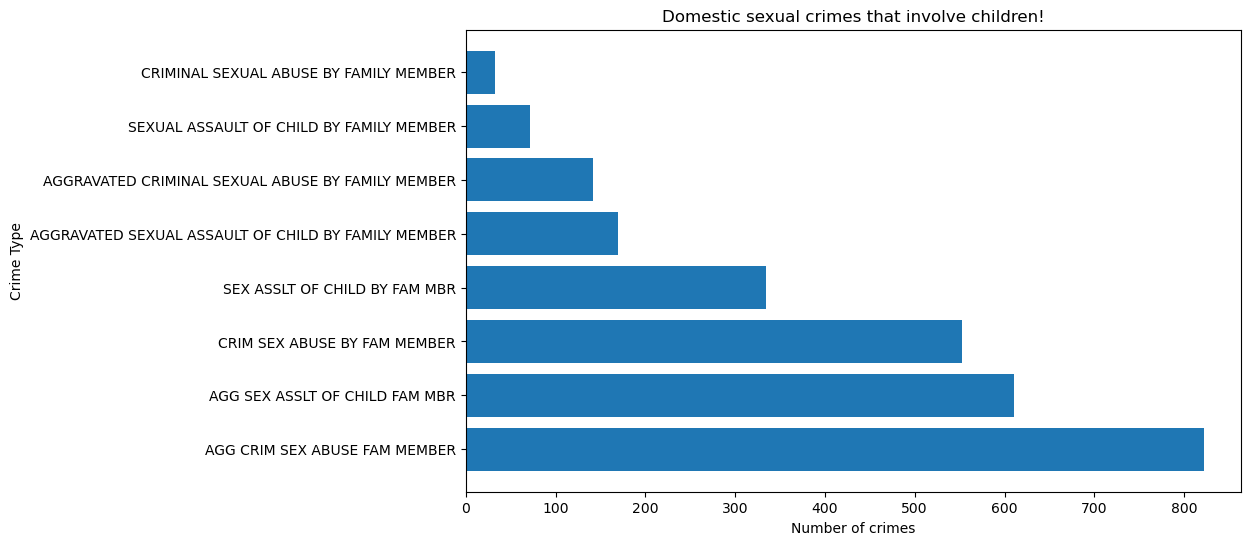

In [33]:
plt.figure(figsize=(10, 6))
plt.barh(children_sex_crimes.index, children_sex_crimes.values)
plt.title('Domestic sexual crimes that involve children!')
plt.xlabel('Number of crimes')
plt.ylabel('Crime Type')
plt.show()

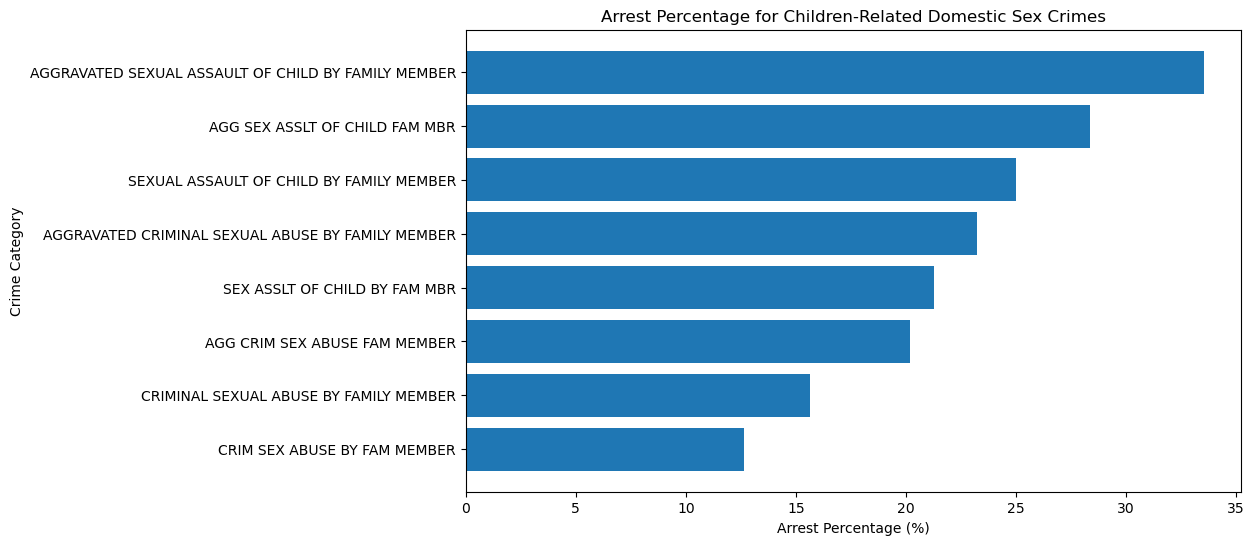

In [34]:
arrest_percentages_df = arrest_percentages_df.sort_values('Arrest')

plt.figure(figsize=(10, 6))
plt.barh(
    arrest_percentages_df.index,
    arrest_percentages_df['Arrest']
)

plt.xlabel('Arrest Percentage (%)')
plt.ylabel('Crime Category')
plt.title('Arrest Percentage for Children-Related Domestic Sex Crimes')
plt.show()

**5.6** What period of the day does the specific kind of (domestic) offense against children, with the most recorded arrests, tend do occur? How does it look for all weekdays individually?
        Can you find certain periods of the week that are especially bad? 

    Note: the details of this question is up to you to interpret

**5.7** Looking at any given year as a whole, what's the worst period in terms of domestic number of offenses involving children? Can you find any trends? Does the trend seem to be consistent for every other year? 

    Note: the details of this question is up to you to interpret

# 6 - Bad Boys Bad Boys whatcha gonna do

**6.1** In general, what weekday is a crime most likely to occur? Which day is the safest?

In [35]:
highest_day_crime = chicago_crime_2008_to_2012_df['Date'].dt.day_name().value_counts()
highest_day_crime

Date
Friday       284130
Wednesday    273642
Tuesday      271316
Thursday     269181
Saturday     266355
Monday       263030
Sunday       251393
Name: count, dtype: int64

***Here i count how many crimes occur for each weekday.***

In [36]:
fig = px.bar(
    highest_day_crime,
    x=highest_day_crime.index,
    y= highest_day_crime.values,
    labels={'Date': 'Weekday', 'y': 'Crime Count'},
    title='Crimes per Weekday'
)

fig.show()

**6.2** Which is the most unsafe weekday for you if you'd like to avoid the following:

a) getting your phone stolen by sneaky pickpockets (THEFT) 

b) having your handbag forcibly pulled away (ROBBERY) 

c) getting jumped in an alley (ASSAULT)

a) THEFT

In [37]:
theft_day = chicago_crime_2008_to_2012_df['Primary Type'].str.contains("THEFT", case=False, na=False)
theft_day = chicago_crime_2008_to_2012_df[theft_day]
theft_day = theft_day['Date'].dt.day_name().value_counts()
print(f'The most unsafe weekday for theft is: {theft_day.index[0]}!')

The most unsafe weekday for theft is: Friday!


***This code finds which weekday has the most reported thefts. It filters all theft crimes, counts how many happen on each day of the week, and prints the day with the highest count.***

In [38]:
fig = px.bar(
    theft_day,
    x=theft_day.index,
    y=theft_day.values,
    labels={'Date': 'Weekday', 'y': 'Crime Count'},
    title='Theft crimes per Weekday'
)

fig.show()


b)

In [39]:
robbery_day = chicago_crime_2008_to_2012_df['Primary Type'].str.contains("ROBBERY", case=False, na=False)
robbery_day = chicago_crime_2008_to_2012_df[robbery_day]
robbery_day = robbery_day['Date'].dt.day_name().value_counts()
print(f'The most unsafe weekday for robbery is: {robbery_day.index[0]}!')

The most unsafe weekday for robbery is: Friday!


***This code finds which weekday has the most reported robbery. It filters all theft crimes, counts how many happen on each day of the week, and prints the day with the highest count.***

In [40]:
fig = px.bar(
    robbery_day,
    x=robbery_day.index,
    y=robbery_day.values,
    labels={'Date': 'Weekday', 'y': 'Crime Count'},
    title='Robbery crimes per Weekday'
)

fig.show()

c)

In [41]:
assault_day = chicago_crime_2008_to_2012_df['Primary Type'].str.contains("ASSAULT", case=False, na=False)
assault_day = chicago_crime_2008_to_2012_df[assault_day]
assault_day = assault_day['Date'].dt.day_name().value_counts()
print(f'The most unsafe weekday for assault is: {assault_day.index[0]}!')

The most unsafe weekday for assault is: Wednesday!


***This code finds which weekday has the most reported assaults. It filters all theft crimes, counts how many happen on each day of the week, and prints the day with the highest count.***

In [42]:
fig = px.bar(
    assault_day,
    x= assault_day.index,
    y= assault_day.values,
    labels={'Date': 'Weekday', 'y': 'Crime Count'},
    title='Assault crimes per Weekday'
)

fig.show()

**6.3** Which are the worst 10 dates (most recorded crimes) of 2008? Does this trend hold for the other years?

In [43]:
top_10_days = chicago_crime_2008_to_2012_df['Date'].dt.year == 2008
top_10_days = chicago_crime_2008_to_2012_df[top_10_days]['Date'].dt.date.value_counts().head(10)
print(f'The worst 10 dates of 2008 are: {top_10_days}')

The worst 10 dates of 2008 are: Date
2008-01-01    1836
2008-08-01    1531
2008-11-01    1480
2008-09-01    1469
2008-10-10    1453
2008-05-01    1450
2008-10-31    1444
2008-08-22    1440
2008-06-01    1438
2008-08-15    1436
Name: count, dtype: int64


***This code finds the 10 single dates in 2008 with the most recorded crimes. It first filters all crimes from 2008, counts how many happened on each specific date, and then shows the top 10 dates with the highest crime counts..***

In [44]:
fig = px.bar(
    x=top_10_days.index,
    y=top_10_days.values,
    labels={'x': 'Date', 'y': 'Crime Count'},
    title='Worst 10 dates of 2008!'
)

fig.update_layout(xaxis_type='category')
fig.show()

**6.4** From the perspective of total number of crime records, which are the Top 10 primary crime types? Which are the Bottom 10? 

Consider this question for the years 2008-2012 as a whole. 

In [45]:
top_crimes = chicago_crime_2008_to_2012_df['Primary Type'].value_counts().head(10)
top_crimes

Primary Type
THEFT                  396789
BATTERY                329385
CRIMINAL DAMAGE        214408
NARCOTICS              207540
BURGLARY               128871
OTHER OFFENSE          111876
ASSAULT                110157
MOTOR VEHICLE THEFT     89270
ROBBERY                 74426
DECEPTIVE PRACTICE      67966
Name: count, dtype: int64

***This code counts how many times each crime type appears in the dataset, sorts them from most to least frequent, and returns the top 10 most common crime types. It basically shows which crimes happen the most.***

In [46]:
fig = px.bar(
    top_crimes,
    x=top_crimes.index,
    y=top_crimes.values,
    labels={'Primary Type': 'Crime Type', 'y': 'Crime Count'},
    title='Top 10 crimes of 2008-2012!'
)

fig.show()

In [47]:
bottom_crimes = chicago_crime_2008_to_2012_df['Primary Type'].value_counts().tail(10)
bottom_crimes

Primary Type
ARSON                       2755
HOMICIDE                    2365
KIDNAPPING                  1467
INTIMIDATION                1017
STALKING                     935
CRIMINAL SEXUAL ASSAULT      371
OBSCENITY                    134
PUBLIC INDECENCY              51
OTHER NARCOTIC VIOLATION      36
HUMAN TRAFFICKING              2
Name: count, dtype: int64

***This code is the same as the code before, only that it shows the last top 10 crimes instead***

In [48]:
px.pie(bottom_crimes, 
       values=bottom_crimes.values, 
       names=bottom_crimes.index,
       title='Bottom 10 crimes of period 2008-2012!'
       )

**6.5** For all those crime categories you identified in 6.4, how does their distribution instead look per year - rather than the full 2008-2012 period as a whole?

In [49]:
top_filtered = chicago_crime_2008_to_2012_df[chicago_crime_2008_to_2012_df['Primary Type'].isin(top_crimes.index)]

yearly_distribution = (
    top_filtered
    .groupby([top_filtered['Date'].dt.year, 'Primary Type'])
    .size()
    .reset_index(name='Count')
)

yearly_distribution.columns = ['Year', 'Primary Type', 'Count']

***This code counts how many of the top 10 crimes happened each year. It makes a table showing year, crime type, and number of crimes.***

In [50]:
fig = px.line(
    yearly_distribution,
    x='Year',
    y='Count',
    color='Primary Type',
    markers=True,
    title='Yearly distribution of top crime types (2008-2012)'
)

fig.update_layout(
    xaxis_title='Year',
    yaxis_title='Crime Count'
)

fig.update_xaxes(dtick=1)
fig.show()

In [51]:
bottom_filtered = chicago_crime_2008_to_2012_df[chicago_crime_2008_to_2012_df['Primary Type'].isin(bottom_crimes.index)]

yearly_distribution = (
    bottom_filtered
    .groupby([bottom_filtered['Date'].dt.year, 'Primary Type'])
    .size()
    .reset_index(name='Count')
)

yearly_distribution.columns = ['Year', 'Primary Type', 'Count']


***This code does the same as the previous one but for the least common crimes. It counts how many of these “bottom” crimes happened each year and makes a table with year, crime type, and count.***

In [52]:
fig = px.line(
    yearly_distribution,
    x='Year',
    y='Count',
    color='Primary Type',
    markers=True,
    title='Yearly distribution of bottom crime types (2008-2012)'
)

fig.update_layout(
    xaxis_title='Year',
    yaxis_title='Crime Count'
)

fig.update_xaxes(dtick=1)
fig.show()


**6.6** Which primary crime types does the city of Chicago seem to get better at preventing? For which ones is it the opposite, i.e, the situation is getting worse? 

In [53]:
crimes_2008_counts = total_crimes_2008.value_counts()
crimes_2012_counts = total_crimes_2012.value_counts()

crime_compare = pd.DataFrame({
    '2008': crimes_2008_counts,
    '2012': crimes_2012_counts
}).fillna(0)

crime_compare['Change'] = crime_compare['2012'] - crime_compare['2008']
crime_compare_top = crime_compare.sort_values('Change').head(10)

***This code compares crime counts between 2008 and 2012. It creates a table showing counts for each year, calculates the change, and then keeps the 10 crime types that decreased the most.***

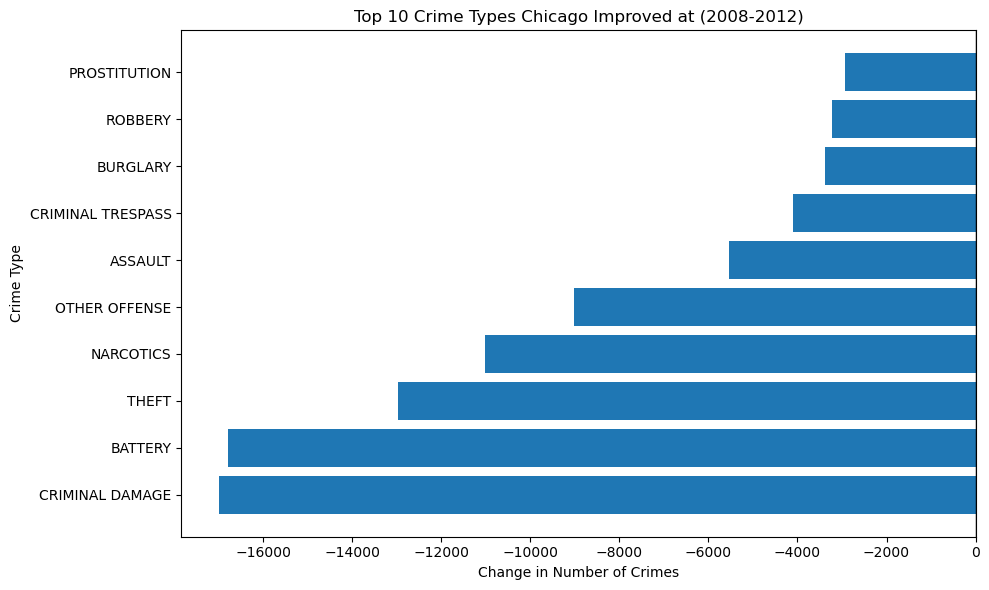

In [54]:
plt.figure(figsize=(10, 6))
plt.barh(crime_compare_top.index, crime_compare_top['Change'])
plt.title('Top 10 Crime Types Chicago Improved at (2008-2012)')
plt.xlabel('Change in Number of Crimes')
plt.ylabel('Crime Type')
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

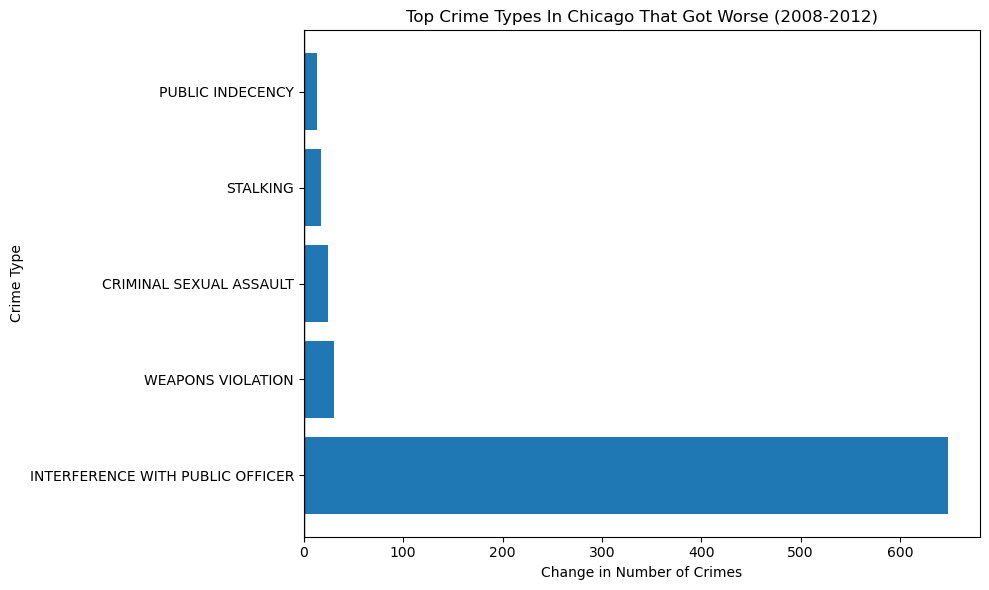

In [55]:
crime_compare_worse = crime_compare.sort_values('Change', ascending=False).head()

plt.figure(figsize=(10, 6))
plt.barh(crime_compare_worse.index, crime_compare_worse['Change'])
plt.title('Top Crime Types In Chicago That Got Worse (2008-2012)')
plt.xlabel('Change in Number of Crimes')
plt.ylabel('Crime Type')
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()


***This code plots the top 5 crime types that got worse between 2008 and 2012. The horizontal bars show how much each crime increased. I decided to print only 5 crimes because there was not enough data for 10 and it didn't look good on the plot***

# 7 - Night Stalker

**7.1** Are there more or less crimes reported during daytime, compared with nighttime? Daytime is considered as all hours between 06:00-18:00, nighttime is the rest of the day.

In [56]:
valid_time = chicago_crime_2008_to_2012_df['Date'].notnull()

daytime_mask = valid_time & (
    (chicago_crime_2008_to_2012_df['Date'].dt.time >= datetime.time(6, 0)) &
    (chicago_crime_2008_to_2012_df['Date'].dt.time < datetime.time(18, 0))
)

nighttime_mask = valid_time & ~daytime_mask

daytime_count = chicago_crime_2008_to_2012_df[daytime_mask].shape[0]
nighttime_count = chicago_crime_2008_to_2012_df[nighttime_mask].shape[0]

print(f"Daytime crimes: {daytime_count}")
print(f"Nighttime crimes: {nighttime_count}")

Daytime crimes: 962914
Nighttime crimes: 916133


***This code counts how many crimes happened during daytime (6:00–18:00) and how many during nighttime (the rest of the day). It first makes sure only rows with a valid Date are used. Then it prints the totals for both periods.***

In [57]:
day_night_df = pd.DataFrame({
    'Period': ['Daytime', 'Nighttime'],
    'Crime Count': [daytime_count, nighttime_count]
})

fig = px.bar(
    day_night_df,
    x='Period',
    y='Crime Count',
    text='Crime Count',
    color='Period',
    title='Daytime vs Nighttime Crimes (2008-2012)'
)

fig.update_traces(textposition='outside')
fig.update_layout(yaxis_title='Number of Crimes')

fig.show()

**7.2** Are there any specific primary crime types that most often occur during nights? Which ones are they?

In [58]:
most_crimes_nighttime = chicago_crime_2008_to_2012_df[nighttime_mask]['Primary Type'].value_counts().head(10)

***This line filters the dataset to include only nighttime crimes (using nighttime_mask) and then counts how many times each primary crime type occurs. Finally, it selects the top 10 most frequent nighttime crime types.***

In [59]:
fig = px.bar(
    most_crimes_nighttime,
    x=most_crimes_nighttime.index,
    y=most_crimes_nighttime.values,
    labels={'Primary Type': 'Crime Type', 'y': 'Crime Count'},
    title='Most 10 crimes that occur during night!'
)

fig.show()

**7.3** In general, for each weekday, how many crimes are recorded during daytime and how many during nighttime? What are the trends? Are there any weekdays that stands out somehow?

In [60]:
weekday_daytime_crimes = chicago_crime_2008_to_2012_df[daytime_mask]['Date'].dt.day_name().value_counts()
weekday_daytime_crimes

Date
Wednesday    148847
Friday       148495
Tuesday      147483
Thursday     144934
Monday       141941
Saturday     121005
Sunday       110209
Name: count, dtype: int64

***This counts how many crimes happened during daytime for each weekday. The day_name() converts the date to the weekday name and value_counts() gives us the total crimes per weekday***

In [61]:
fig = px.line(weekday_daytime_crimes, 
              x=weekday_daytime_crimes.index, 
              y=weekday_daytime_crimes.values, 
              title='Weekdays with most crimes during daytime!' ,
              labels={'Date':'Weekday','y':'Crime Count'} , 
              markers=True)
fig.show()

In [62]:
weekday_nighttime_crimes = chicago_crime_2008_to_2012_df[nighttime_mask]['Date'].dt.day_name().value_counts()
weekday_nighttime_crimes

Date
Saturday     145350
Sunday       141184
Friday       135635
Wednesday    124795
Thursday     124247
Tuesday      123833
Monday       121089
Name: count, dtype: int64

***Same as the code before, only that it counts how many crimes happened during nighttime for each weekday.***

In [63]:
fig = px.line(weekday_nighttime_crimes,
              x=weekday_nighttime_crimes.index,
              y=weekday_nighttime_crimes.values,
              title='Weekdays with most crimes during nighttime!',
              labels={'Date': 'Weekday', 'y': 'Crime Count'},
              markers=True)
fig.show()

Monday, Tuesday, Wednesday, Thursday and Friday have overwhelmingly more recorded crimes during the day, than during the night.

Saturday also has more records during the day, but it's only slightly more than durnig the night.

Sunday is a trend breaker - wherein the number of recorded crimes are higher during the night, than during the night. Though not by alot.

**7.4** Does the trends you've found in 7.3 also hold if you look at each year individually?

In [64]:
results_night = {}

for yr in years:
    df_year = chicago_crime_2008_to_2012_df[chicago_crime_2008_to_2012_df['Year'] == yr]        # Filter by year
    night_mask_year = nighttime_mask[df_year.index]                                             # Apply nighttime mask for that year
    night_counts = df_year[night_mask_year]['Date'].dt.day_name().value_counts()                # Count crimes per weekday
    results_night[yr] = night_counts

# Convert to DataFrame
night_df = pd.DataFrame(results_night)
print(night_df)

            2008   2009   2010   2011   2012
Date                                        
Friday     31867  28368  27359  24735  23306
Monday     28091  25136  23780  22681  21401
Saturday   33871  30326  27600  27706  25847
Sunday     32486  29258  27162  26429  25849
Thursday   28275  26762  24998  22581  21631
Tuesday    29625  26397  24042  22272  21497
Wednesday  29457  26592  24450  22436  21860


***This table shows the number of nighttime crimes for each weekday, split by year from 2008 to 2012. Each column represents a year, and each row represents a weekday. From this, we can see which weekdays tend to have more crimes during nighttime and observe how the pattern changes year by year.***

In [65]:
fig_night = px.line(
    night_df,
    x=night_df.index,
    y=night_df.columns,
    title="Nighttime Crimes per Weekday (2008–2012)",
    labels={'x': 'Weekday', 'value': 'Crime Count', 'variable': 'Year'},
    markers=True
)

fig_night.show()

**7.5** Are there any weekdays in which Stalking occurs more often during nighttime?

In [66]:
stalking_day = chicago_crime_2008_to_2012_df['Primary Type'].str.contains("STALKING", case=False, na=False)
stalking_day = chicago_crime_2008_to_2012_df[stalking_day]
stalking_day = stalking_day[nighttime_mask]['Date'].dt.day_name().value_counts()

print(f'Stalking during nighttime occurs more on: {stalking_day.index[0]}')

Stalking during nighttime occurs more on: Monday


***The code first filters all crimes that are related to stalking. Then it applies the nighttime mask. Finally, it counts how many stalking crimes occurred on each weekday at night and identifies the day with the highest number***

In [67]:
fig = px.line(stalking_day,
              x=stalking_day.index,
              y=stalking_day.values,
              title='Weekdays with most stalking crimes during nighttime!',
              labels={'Date': 'Weekday', 'y': 'Crime Count'},
              markers=True)
fig.show()

# 8 - Grand Theft Auto

**8.1** You just bought a new car. What weekday should you be most wary of as it has the highest risk for a Grand Theft Auto-style robbery (MOTOR VEHICLE THEFT)?

In [68]:
car_theft = chicago_crime_2008_to_2012_df['Primary Type'].str.contains("MOTOR VEHICLE THEFT", case=False, na=False)
car_theft_weekday = chicago_crime_2008_to_2012_df[car_theft]['Date'].dt.day_name().value_counts()
car_theft_weekday

Date
Friday       13622
Thursday     13058
Wednesday    13045
Monday       13027
Tuesday      12714
Saturday     12106
Sunday       11698
Name: count, dtype: int64

***The code filters the dataset to include only crimes related to motor vehicle theft. Then it extracts the weekday for each theft and counts how many thefts happened on each day of the week. The result shows which weekdays have the most car thefts.***

In [69]:
fig = px.line(car_theft_weekday,
              x=car_theft_weekday.index,
              y=car_theft_weekday.values,
              title='Weekdays with most car thieft crimes!',
              labels={'Date': 'Weekday', 'y': 'Crime Count'},
              markers=True)
fig.show()

**8.2** For that day, where (at what location) should you absolutely avoid leave your car carelessly? Where is it seemingly safest to do so?

In [70]:
car_theft_location = chicago_crime_2008_to_2012_df[car_theft]
car_theft_location = car_theft_location[car_theft_location['weekday'] == 'Friday']

In [71]:
location_counts = (
    car_theft_location
    .groupby(['Latitude', 'Longitude'])
    .size()
    .reset_index(name='count')
)

location_counts = location_counts.sort_values('count', ascending=False)

top5 = location_counts.head(10)
bottom5 = location_counts.tail(10)

***The code first filters the dataset to include only motor vehicle thefts that happened on Fridays. Then it groups the crimes by latitude and longitude to count how many thefts happened at each location. Finally, it sorts the locations by the number of thefts, storing the 10 locations with the most thefts in top5 and the 10 locations with the fewest thefts in bottom5***

In [72]:
fig = px.scatter_map(top5, lat='Latitude', lon='Longitude', size='count' ,zoom=9, title='Top 10 worst location to leave your car!')
fig.update_traces(cluster=dict(enabled=True))
fig.show()

In [73]:
fig = px.scatter_map(bottom5, lat='Latitude',lon='Longitude', size='count', zoom=8, title='Best 10 locations to leave your car!')
fig.update_traces(cluster=dict(enabled=True))
fig.show()

**8.3*** Are there certain periods of the year/month/day/time of day where GTA is more frequent?

In [74]:
gta_by_month = car_theft_location['Date'].dt.month.value_counts()
gta_by_month

Date
10    1265
7     1238
8     1227
12    1188
6     1165
5     1145
9     1116
1     1111
4     1096
11    1080
3     1068
2      923
Name: count, dtype: int64

***The code counts how many car thefts (GTA) happened in each month. Then it converts that count into a DataFrame and uses a heatmap to visualize the results***

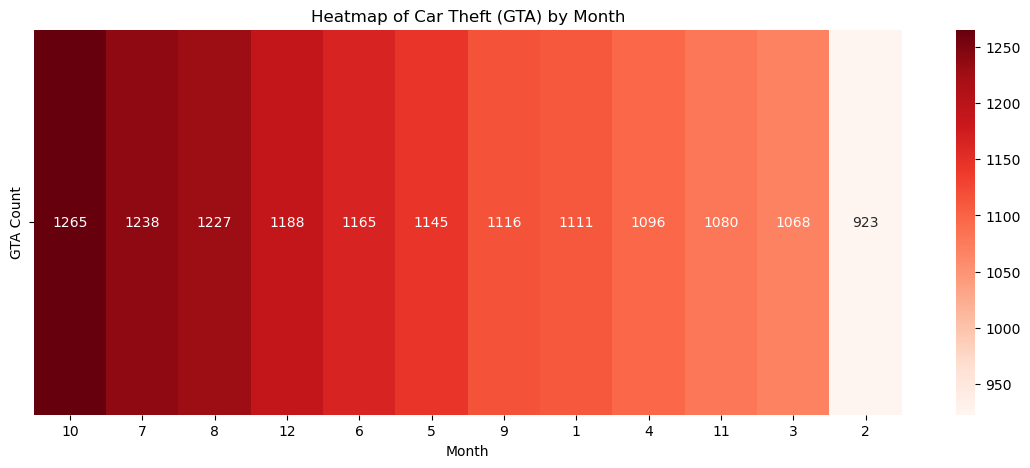

In [75]:
gta_month_df = pd.DataFrame(gta_by_month).T
gta_month_df.index = ["GTA Count"]  # rename row for readability

plt.figure(figsize=(14, 5))
sns.heatmap(gta_month_df, annot=True, fmt="d", cmap="Reds")
plt.title("Heatmap of Car Theft (GTA) by Month")
plt.xlabel("Month")
plt.ylabel("")
plt.show()

# 9. Just send me like location

https://www.youtube.com/watch?v=k7yBJ5Ffkdo

**9.1** Are there any (geographical) areas hit particularly hard by prostitution on friday nights?

**9.2** Can you vizualise the locations from 9.1 on a map of Chicago? Is there a concentration somewhere? 

**9.3*** Can you find any geographical concentration of other crime categories? Perhaps even by weekday and or day/nighttime? Plot these on a map of Chicago. 

# 10 - The $ factor

**10.1** Merge the crime and census datasets together in a suitable way.

In [76]:
merged_df = pd.merge(
    chicago_crime_2008_to_2012_df,
    chicago_census_2008_to_2012_df,
    left_on='Community Area',
    right_on='Community Area Number',
    how='left'
)

In [77]:
merged_df = merged_df.drop(columns=['Community Area Number'])      # This column is the same as Community Area on Chicago crime dataset 
merged_df.head()                                                   # therefore i am removing it.

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,minutes,weekday,COMMUNITY AREA NAME,PERCENT OF HOUSING CROWDED,PERCENT HOUSEHOLDS BELOW POVERTY,PERCENT AGED 16+ UNEMPLOYED,PERCENT AGED 25+ WITHOUT HIGH SCHOOL DIPLOMA,PERCENT AGED UNDER 18 OR OVER 64,PER CAPITA INCOME,HARDSHIP INDEX
0,8953937,HW102973,2012-12-31 23:58:00,037XX N NORA AVE,0610,BURGLARY,FORCIBLE ENTRY,RESIDENCE-GARAGE,False,False,...,58,Monday,Dunning,5.2,10.6,10.0,16.2,33.6,26282.0,28.0
1,8950836,HW100039,2012-12-31 23:55:00,0000X E OHIO ST,2890,PUBLIC PEACE VIOLATION,OTHER VIOLATION,SIDEWALK,True,False,...,55,Monday,Near North Side,1.9,12.9,7.0,2.5,22.6,88669.0,1.0
2,8950918,HW100021,2012-12-31 23:55:00,035XX W MONTROSE AVE,0610,BURGLARY,FORCIBLE ENTRY,OTHER,False,False,...,55,Monday,Irving Park,6.3,13.1,10.0,22.4,31.6,27249.0,34.0
3,8954299,HW100700,2012-12-31 23:55:00,058XX S MARYLAND AVE,0890,THEFT,FROM BUILDING,HOSPITAL BUILDING/GROUNDS,False,False,...,55,Monday,Hyde Park,1.5,18.4,8.4,4.3,26.2,39056.0,14.0
4,8951459,HW100757,2012-12-31 23:50:00,028XX N HALSTED ST,0890,THEFT,FROM BUILDING,RESIDENCE,False,False,...,50,Monday,Lake View,1.1,11.4,4.7,2.6,17.0,60058.0,5.0


***This code merges the crime dataset with the census dataset using the community area as the key. After merging, it drops the redundant Community Area Number column since it’s the same as Community Area in the crime dataset. The result is a combined dataset containing both crime and socioeconomic info***

**10.2*** Are there certain kinds of socoeconomic area that are more prone to certain kinds of crimes? Do a deep dive in the direction you fancy yourself here.

In [78]:
crime_hardship = merged_df.groupby('Primary Type')['HARDSHIP INDEX'].mean().sort_values(ascending=False)
crime_hardship = round(crime_hardship, 2)

print('Average Hardship Index per crime type:')
crime_hardship.head()

Average Hardship Index per crime type:


Primary Type
GAMBLING             71.23
HOMICIDE             67.44
WEAPONS VIOLATION    66.48
NARCOTICS            66.02
PROSTITUTION         65.52
Name: HARDSHIP INDEX, dtype: float64

***This shows the average socioeconomic hardship for each type of crime. Crimes at the top tend to happen more in areas with higher hardship, while those at the bottom occur more in areas with lower hardship. It gives an idea of which crimes are linked to tougher neighborhoods***

In [79]:
fig = px.bar(
    crime_hardship.reset_index(),
    x='Primary Type',
    y='HARDSHIP INDEX',
    title='Average Hardship Index per Crime Type in Chicago',
    labels={'Primary Type': 'Crime Type','HARDSHIP INDEX': 'Average Hardship Index'}
)

fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [80]:
sample_df = merged_df.sample(1000, random_state=42)

fig = px.scatter_mapbox(
    sample_df,
    lat="Latitude",
    lon="Longitude",
    color="HARDSHIP INDEX",
    size_max=8,
    zoom=10,
    hover_name="Primary Type",
    mapbox_style="carto-positron",
    color_continuous_scale="Reds",
    title="Crime Locations Colored by Hardship Index"
)

fig.show()

***This plot shows 1000 crime locations, colored by hardship index. Darker red means higher socioeconomic hardship, and hovering shows the crime type. It helps see how crime relates to area hardship***

# 11 - Your turn!

There are obviously so much more to gain by analysing these datasets. This is now your opportunity to dwelve deeper into what you yourself like.

    Instructions: think of one or several questions (as we've done above). Then, proceed with your own deep dive analysis and provide your answers.